# MAJOR PROJECT 

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Topic - Study Location & Study Experience Of Student


The project studies whether the place where a student studies affects how productive they feel. Collected survey data from 83 students and used data analysis, visualizations, and a machine learning model to find patterns and insights.

How was the data collected?

Through a Google Form survey. 83 students responded. The form had 17 questions covering demographics, study habits, productivity ratings, distractions, library usage, and exam behaviour.

In [5]:
df = pd.read_csv("Study Location vs Productivity  - Survey.csv")
print(f"Original shape: {df.shape}")

Original shape: (83, 18)


##  Data Cleaning And Preprocessing

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83 entries, 0 to 82
Data columns (total 18 columns):
 #   Column                                                                                               Non-Null Count  Dtype  
---  ------                                                                                               --------------  -----  
 0   Your Academic Program ?                                                                              83 non-null     object 
 1   Year of Study                                                                                        83 non-null     object 
 2    What is your gender ?                                                                               83 non-null     object 
 3     Where do you usually study? (Primary location)                                                     83 non-null     object 
 4   Do you use the library for studying?                                                                 83 non-null

In [7]:
df.drop(columns=df.columns[17], inplace=True)

Column renaming.

In [8]:
new_columns = [               
    "program",                  
    "year",                     
    "gender",                   
    "primary_location",         
    "library_usage",            
    "daily_study_hours",        
    "study_routine",            
    "productivity_home",        
    "productivity_library",     
    "productivity_class",       
    "productivity_boosters",    
    "easily_distracted",        
    "main_distractions",        
    "library_visit_reasons",    
    "avoid_library_reasons",    
    "exam_study_intensity",     
    "exam_location_change"     

]

In [9]:
df.columns = new_columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83 entries, 0 to 82
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   program                83 non-null     object
 1   year                   83 non-null     object
 2   gender                 83 non-null     object
 3   primary_location       83 non-null     object
 4   library_usage          83 non-null     object
 5   daily_study_hours      83 non-null     object
 6   study_routine          83 non-null     object
 7   productivity_home      83 non-null     object
 8   productivity_library   83 non-null     object
 9   productivity_class     83 non-null     object
 10  productivity_boosters  83 non-null     object
 11  easily_distracted      83 non-null     object
 12  main_distractions      83 non-null     object
 13  library_visit_reasons  83 non-null     object
 14  avoid_library_reasons  82 non-null     object
 15  exam_study_intensity   83

Renaming the responses to  be easily interpreted.

In [10]:
df["year"] = df["year"].replace({
    "1st Year": "Year 1",
    "2nd Year": "Year 2",
    "3rd Year": "Year 3",
    "4th Year": "Year 4",
    "Final Year(M. Tech / M. Sc)":"Final Year",
    "PhD Scholar": "PhD",
})


df["primary_location"] = df["primary_location"].replace({
    "Hostel Room /Home":   "Hostel",
    "Classroom /Lab":      "Lab/Classroom",
    "Library":             "Library",     
})


df["library_usage"] = df["library_usage"].replace({
    "Yes, regularly":  "Regularly",
    "Sometimes":       "Sometimes",
    "Rarely":          "Rarely",
    "Never":           "Never",
})


df["daily_study_hours"] = df["daily_study_hours"].replace({
    "Less than 2 hour":    "<2 hrs",
    "2–4 hours":           "2-4 hrs",
    "More than 4 hours":   ">4 hrs",
})

NOT_SPOT = "Not my study spot (yet) 👀"
for col in ["productivity_home", "productivity_library", "productivity_class"]:
    df[col] = df[col].replace({NOT_SPOT: 0})
    df[col] = pd.to_numeric(df[col], errors="coerce")


df["exam_study_intensity"] = df["exam_study_intensity"].replace({
    "Yes, significantly more":  "Significantly more",
    "Slightly more":            "Slightly more",    
    "Same":                     "Same",             
    "Less":                     "Less",             
})

df["exam_location_change"] = df["exam_location_change"].replace({
    "No change":                    "No change",
    "Yes → I prefer home/hostel":   "Yes - Hostel",
    "Yes → I prefer library":       "Yes - Library",
})

In [11]:
print("RENAMED COLUMNS ")
for col in df.columns:
    print(f"  {col}")

RENAMED COLUMNS 
  program
  year
  gender
  primary_location
  library_usage
  daily_study_hours
  study_routine
  productivity_home
  productivity_library
  productivity_class
  productivity_boosters
  easily_distracted
  main_distractions
  library_visit_reasons
  avoid_library_reasons
  exam_study_intensity
  exam_location_change


In [12]:
df.to_csv("cleaned_data.csv", index=False)
df.to_excel("cleaned_data.xlsx", index=False)

## EDA and Visualization

In [13]:
prod_cols   = ["productivity_home", "productivity_library", "productivity_class"]
prod_labels = ["Hostel", "Library", "Classroom/Lab"]

In [14]:
from collections import Counter

df = df
df['avg_productivity'] = df[['productivity_home', 'productivity_library', 'productivity_class']].mean(axis=1)

def count_multi(series, top_n=8):
    items = []
    for val in series.dropna():
        items.extend([x.strip() for x in str(val).split(",")])
    return pd.Series(Counter(items)).nlargest(top_n)

YEAR_ORDER  = ["Year 1", "Year 2", "Year 3", "Year 4", "Final Year", "PhD"]
HOURS_ORDER = ["<2 hrs", "2-4 hrs", ">4 hrs"]
LIB_ORDER   = ["Never", "Rarely", "Sometimes", "Regularly"]
EXAM_ORDER  = ["Less", "Same", "Slightly more", "Significantly more"]

TOPIC 1 — DEMOGRAPHICS

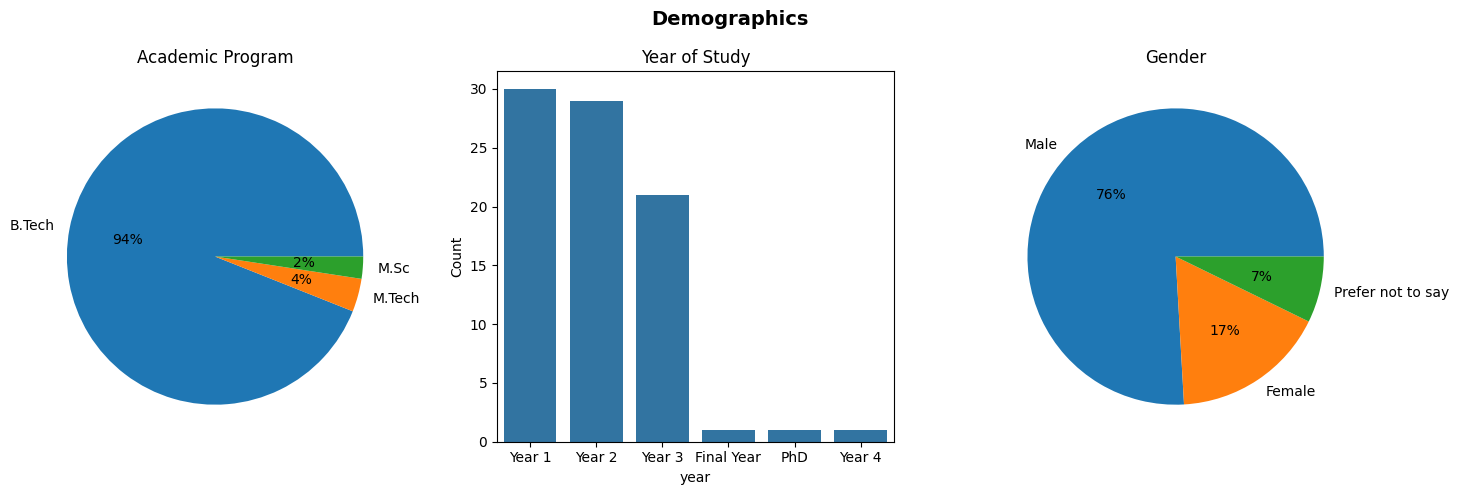

In [39]:
plt.figure(figsize=(15,5))
plt.suptitle("Demographics", fontsize=14, fontweight="bold")
plt.subplot(1,3,1)
df["program"].value_counts().plot.pie(autopct="%1.0f%%")
plt.title("Academic Program")
plt.ylabel("")

plt.subplot(1,3,2)
year_counts = df["year"].value_counts()
sns.barplot(x=year_counts.index, y=year_counts.values)
plt.title("Year of Study")
plt.ylabel("Count")

plt.subplot(1,3,3)
df["gender"].value_counts().plot.pie(autopct="%1.0f%%")
plt.title("Gender")
plt.ylabel("")

plt.tight_layout()
plt.show()

 Academic Program:

Almost everyone surveyed (94%) is a B.Tech student, so the results mainly reflect their habits, not the whole college.

Year of Study :

Most responses come from juniors — about 72% are from Year 1 and 2. Very few seniors responded, so their perspective is mostly missing.

Gender :
The group is mostly male (76%), with fewer females (17%).

TOPIC 2 — STUDY BEHAVIOUR OVERVIEW

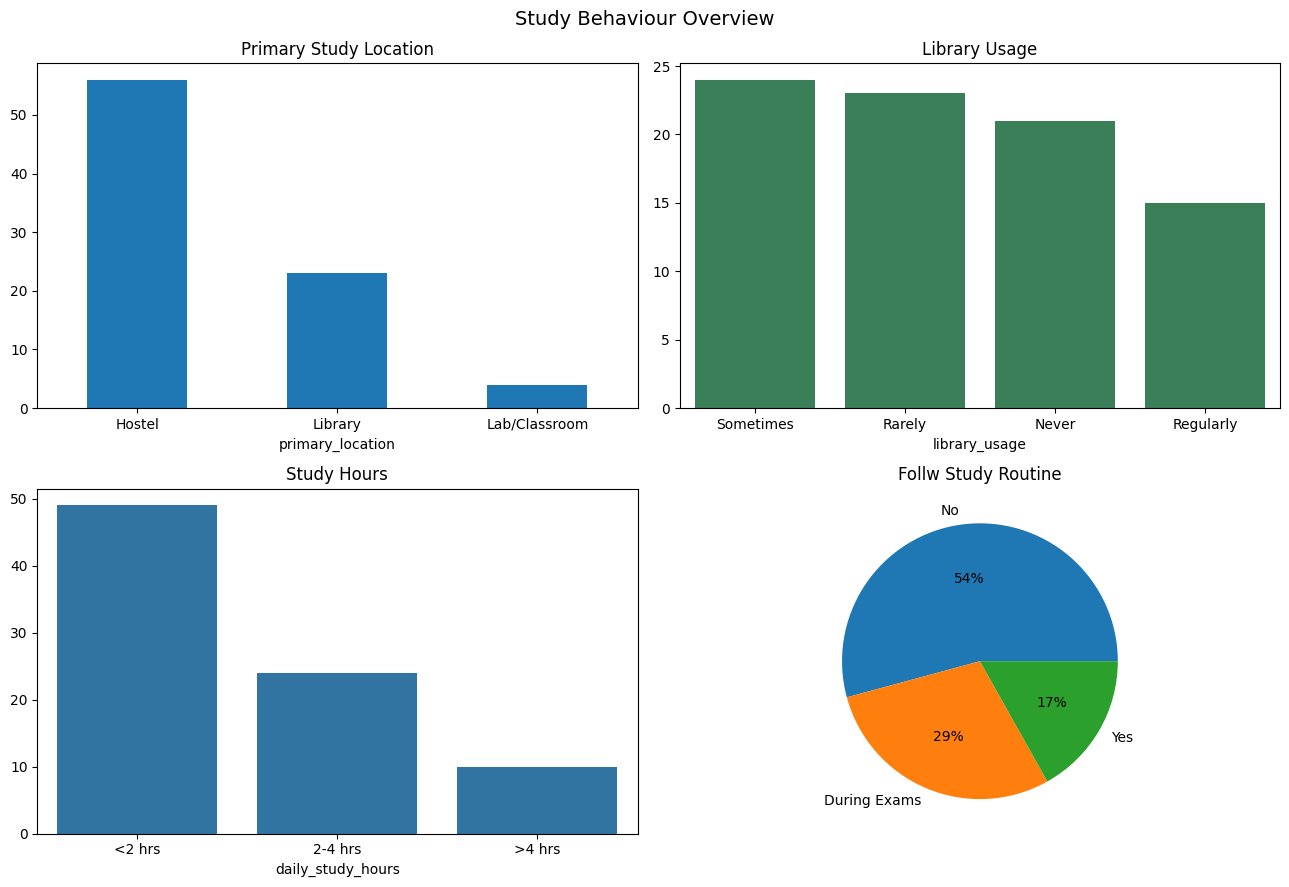

In [38]:
plt.figure(figsize=(13,9))
plt.suptitle("Study Behaviour Overview", fontsize=14)
plt.subplot(2,2,1)
df["primary_location"].value_counts().plot(kind="bar")
plt.title("Primary Study Location")
plt.xticks(rotation=0)


plt.subplot(2,2,2)
lib_counts = df["library_usage"].value_counts()
sns.barplot(x=lib_counts.index, y=lib_counts.values,color="seagreen")
plt.title("Library Usage")
plt.xticks(rotation=0)


plt.subplot(2,2,3)
hours_counts = df["daily_study_hours"].value_counts()
sns.barplot(x=hours_counts.index, y=hours_counts.values)
plt.title("Study Hours")
plt.xticks(rotation=0)

plt.subplot(2,2,4)
df["study_routine"].value_counts().plot.pie(autopct="%1.0f%%")
plt.title("Follw Study Routine")
plt.ylabel("")

plt.tight_layout()
plt.show()

The majority of students  primarily study at Hostel, while 27.7% prefer the Library and only 4.8% use Lab/Classroom as their go-to study space. This suggests that most students default to personal, comfortable spaces over institutional ones.

When it comes to library usage, only 15% visit regularly, while the remaining 85% use it sometimes, rarely, or never. This is notable given that 22 % listed the library as their primary location — indicating that even students who prefer the library don't necessarily use it consistently.

Study hours are on the lower end overall — 49  of students study less than 2 hours per day, 24 study 2–4 hours, and only 20 exceed 4 hours. This points to a generally low daily study investment among the surveyed population.

The study routine data reinforces this pattern. 54% of students follow no fixed routine, 29% only maintain one during exams, and just 17% follow a routine consistently. Combined with the low daily study hours, this indicates that structured, disciplined study habits are the exception rather than the norm in this group.

TOPIC 3 — PRODUCTIVITY RATINGS BY LOCATION

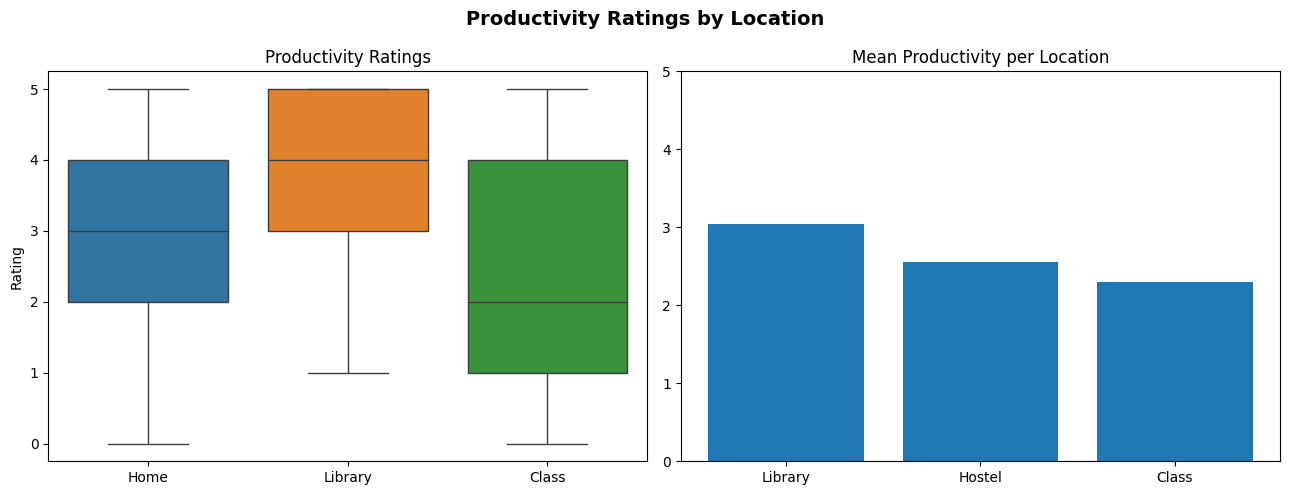

In [35]:
plt.figure(figsize=(13,5))
plt.suptitle("Productivity Ratings by Location", fontsize=14, fontweight="bold")
# ---- Boxplot ----
plt.subplot(1,2,1)

# basic conversion (no fancy melt)
data = [
    df["productivity_home"],
    df["productivity_library"][df["productivity_library"] > 0],
    # df["productivity_library"]>0,
    df["productivity_class"]
]

sns.boxplot(data=data)
plt.xticks([0,1,2], ["Home", "Library", "Class"])
plt.title("Productivity Ratings")
plt.ylabel("Rating")

# ---- Mean comparison ----
plt.subplot(1,2,2)

means = [
    df["productivity_home"].mean(),
    df["productivity_library"].mean(),
    df["productivity_class"].mean()
]

labels = ["Library", "Hostel", "Class"]

plt.bar(labels, means)
plt.title("Mean Productivity per Location")
plt.ylim(0,5)

plt.tight_layout()
plt.show()

- Library has the highest mean productivity score (~3), making it the most effective study spot among the three locations.
- Hostel comes second (~3), and Classroom/Lab scores the lowest (~2).
- Despite library being the top rated spot, majority of students still prefer studying at home — showing a gap between "what works" and "what students actually do."
- 19 students rated their non-primary locations as 0 (not their study spot), which slightly pulls the averages down.
- The box plot shows library ratings are more consistently spread between 3–5, meaning students who do use it rarely rate it poorly.
- Overall, location does seem to affect how productive students feel, with a structured environment like library clearly having an edge.

TOPIC 4 — PRIMARY LOCATION vs PRODUCTIVITY

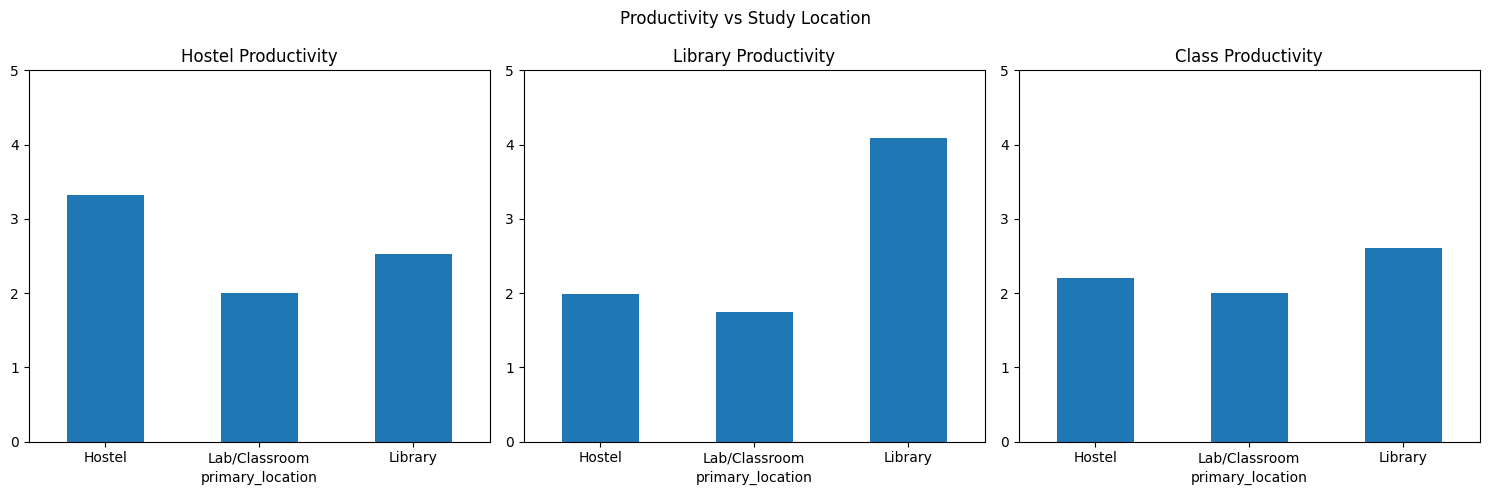

In [18]:
plt.figure(figsize=(15,5))
plt.suptitle("Productivity vs Study Location", fontsize=12)

plt.subplot(1,3,1)
grp1 = df.groupby("primary_location")["productivity_home"].mean()
grp1.plot(kind="bar")
plt.title("Hostel Productivity")
plt.ylim(0,5)
plt.xticks(rotation=0)

plt.subplot(1,3,2)
grp2 = df.groupby("primary_location")["productivity_library"].mean()
grp2.plot(kind="bar")
plt.title("Library Productivity")
plt.ylim(0,5)
plt.xticks(rotation=0)

plt.subplot(1,3,3)
grp3 = df.groupby("primary_location")["productivity_class"].mean()
grp3.plot(kind="bar")
plt.title("Class Productivity")
plt.ylim(0,5)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

- Students  rate their own preferred location higher than others — hostel studiers rate hostel highest, library users rate library highest.
- This shows a comfort bias — students feel more productive where they're already comfortable, not necessarily where they'd actually perform best.
- However, even home/hostel students give the library a decent rating, suggesting they do acknowledge that library is a good study environment.
- Library students rate their location the highest overall, which aligns with Topic 3 findings that library has the best mean productivity score.
- Lab/Classroom gets low ratings across all groups regardless of who's rating it — no group particularly favors it.
- The key takeaway here is that most students know the library is effective but still choose home out of habit and comfort.

TOPIC 5 — DISTRACTION ANALYSIS

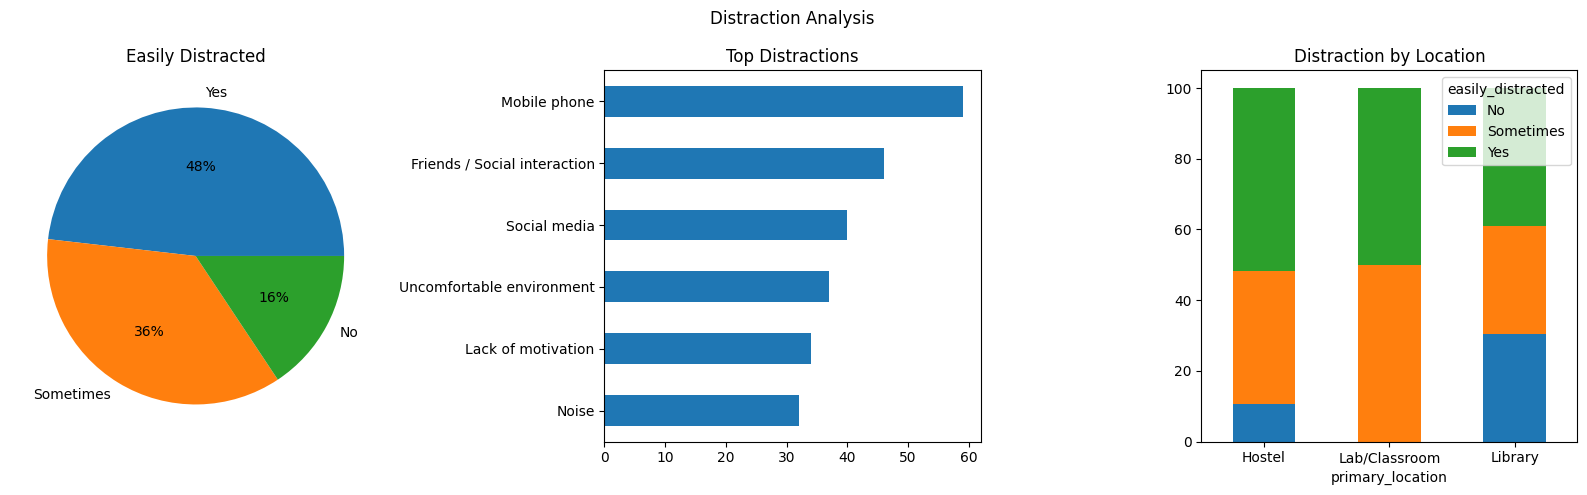

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))
df["easily_distracted"].value_counts().plot.pie(
    ax=axes[0], autopct="%1.0f%%")

axes[0].set_title("Easily Distracted")
axes[0].set_ylabel("")

top_dist = count_multi(df["main_distractions"])
top_dist.sort_values().plot(kind="barh", ax=axes[1])
axes[1].set_title("Top Distractions")

cross = pd.crosstab(df["primary_location"], df["easily_distracted"], normalize="index") * 100
cross.plot(kind="bar", stacked=True, ax=axes[2])
axes[2].set_title("Distraction by Location")
axes[2].tick_params(axis="x", rotation=0)

plt.suptitle("Distraction Analysis")
plt.tight_layout()
plt.show()

- 48% students said they get easily distracted, 36% said sometimes — meaning only 16% are truly focused while studying.
- Mobile phones and social media are the biggest distractions by a large margin.
- Students studying at home face the highest distraction levels, which makes sense since there's no external accountability.
- Library students show the least distraction, supporting the idea that environment plays a big role in focus.
- Noise and friends/roommates also appear frequently as distractors, especially for hostel students.
- Overall, distraction is a widespread issue and home — the most popular study spot — also happens to be the most distracting one.

TOPIC 6 — LIBRARY USAGE PATTERNS

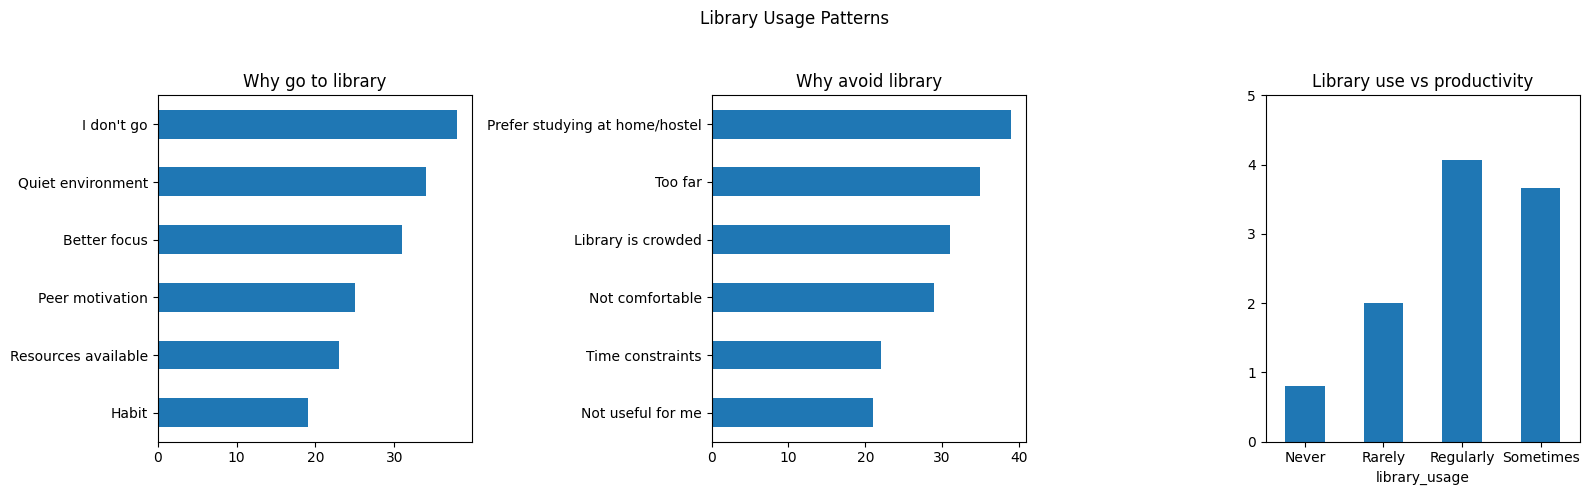

In [20]:
plt.figure(figsize=(16,5))

plt.subplot(1,3,1)
reasons_go = count_multi(df["library_visit_reasons"])
reasons_go.sort_values().plot(kind="barh")
plt.title("Why go to library")

plt.subplot(1,3,2)
reasons_avoid = count_multi(df["avoid_library_reasons"])
reasons_avoid.sort_values().plot(kind="barh")
plt.title("Why avoid library")

plt.subplot(1,3,3)
grp = df.groupby("library_usage")["productivity_library"].mean()
grp.plot(kind="bar")
plt.title("Library use vs productivity")
plt.ylim(0,5)
plt.xticks(rotation=0)


plt.suptitle("Library Usage Patterns")
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

- The top reason students go to the library is for better focus and a quiet environment.
Other common reasons include avoiding distractions at hostel.
- Students who avoid the library mainly say they prefer the comfort of home or find the library too crowded.
- Distance and timing issues also come up as barriers to library usage.
- Importantly, students who visit the library regularly tend to rate their library productivity higher — the more you use it, the better it works for you.
- This suggests that low library usage isn't about it being ineffective, but more about habit and comfort preferences.

TOPIC 7 — EXAM BEHAVIOUR

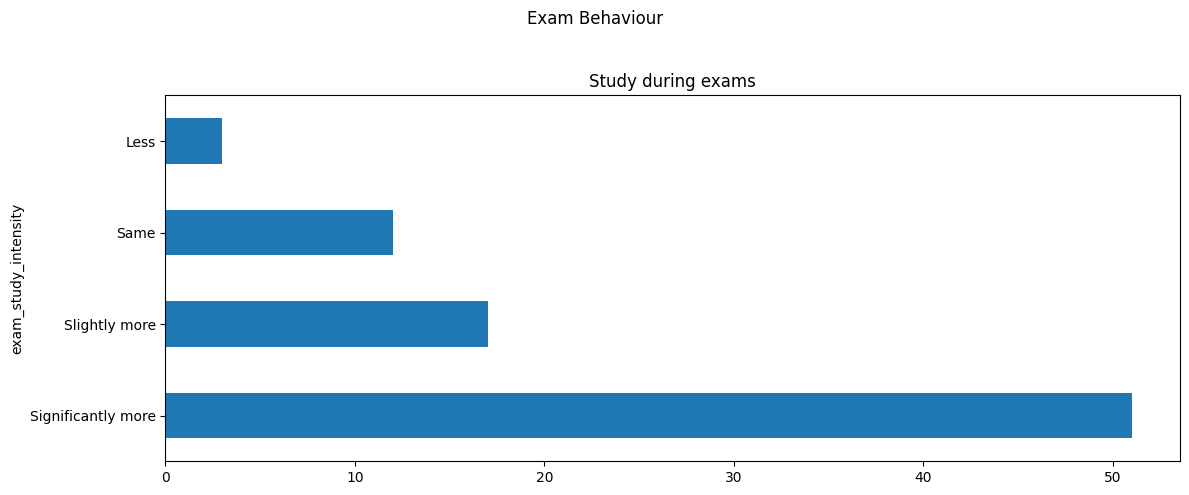

In [43]:
plt.figure(figsize=(12,5))
df["exam_study_intensity"].value_counts().plot(kind="barh")
plt.title("Study during exams")
plt.suptitle("Exam Behaviour")
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

In [42]:
import plotly.express as px

loc_flow = df[["primary_location", "exam_location_change"]].dropna()

loc_flow["exam_location_change"] = loc_flow["exam_location_change"].replace({
    "No change": "No Change",
    "Yes - Library": "Shifted to Library",
    "Yes - Home/Hostel": "Shifted to Home"
})

fig = px.parallel_categories(
    loc_flow,
    dimensions=["primary_location", "exam_location_change"],
    labels={
        "primary_location": "Primary Location",
        "exam_location_change": "During Exams"
    },
    title="Study Location Change During Exams"
)

fig.show()

- 61% of students study significantly more during exams, and another 20 % study slightly more — so almost everyone increases effort during exam time.
- However, 51% don't change their study location even during exams.
- Among those who do shift, a good portion move to the library, showing they recognise it as a better environment when serious studying is needed.
- This tells us that exam pressure increases study time but not always the awareness to switch to a better environment.
- It also shows that students who normally avoid the library do consider it during exams.

TOPIC 8 — CROSS ANALYSIS

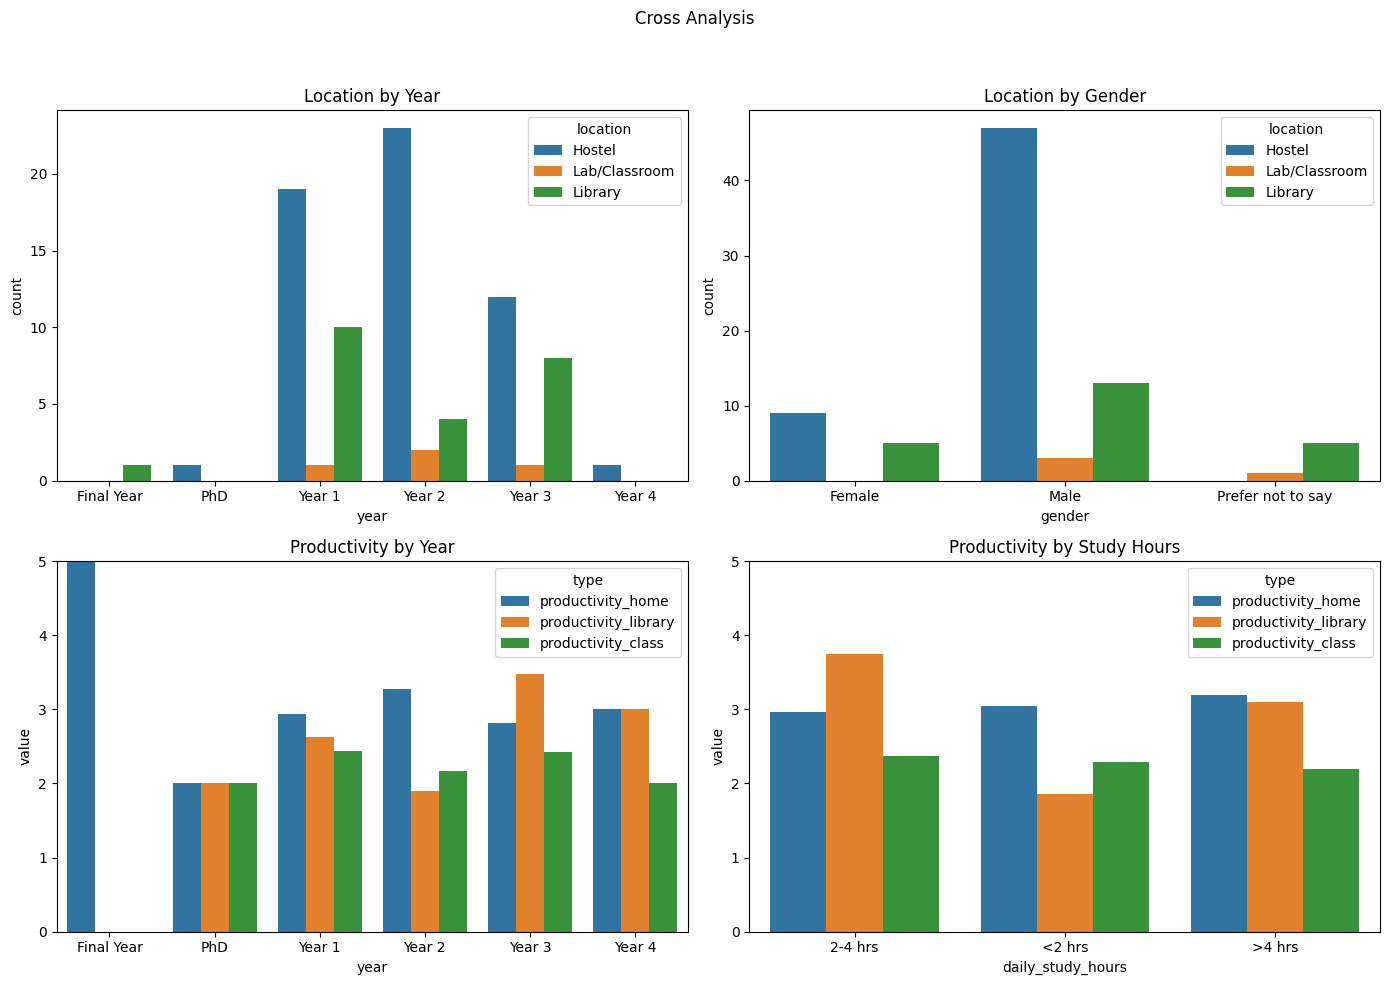

In [22]:
plt.figure(figsize=(14,10))

plt.subplot(2,2,1)
year_loc = pd.crosstab(df["year"], df["primary_location"]).reset_index()
year_loc = year_loc.melt(id_vars="year", var_name="location", value_name="count")
sns.barplot(data=year_loc, x="year", y="count", hue="location")
plt.title("Location by Year")
plt.xticks(rotation=0)


plt.subplot(2,2,2)
gen_loc = pd.crosstab(df["gender"], df["primary_location"]).reset_index()
gen_loc = gen_loc.melt(id_vars="gender", var_name="location", value_name="count")
sns.barplot(data=gen_loc, x="gender", y="count", hue="location")
plt.title("Location by Gender")
plt.xticks(rotation=0)

plt.subplot(2,2,3)
yr_prod = df.groupby("year")[["productivity_home","productivity_library","productivity_class"]].mean().reset_index()
yr_prod = yr_prod.melt(id_vars="year", var_name="type", value_name="value")
sns.barplot(data=yr_prod, x="year", y="value", hue="type")
plt.title("Productivity by Year")
plt.ylim(0,5)


plt.subplot(2,2,4)
hrs_prod = df.groupby("daily_study_hours")[["productivity_home","productivity_library","productivity_class"]].mean().reset_index()
hrs_prod = hrs_prod.melt(id_vars="daily_study_hours", var_name="type", value_name="value")
sns.barplot(data=hrs_prod, x="daily_study_hours", y="value", hue="type")
plt.title("Productivity by Study Hours")
plt.ylim(0,5)

plt.suptitle("Cross Analysis")

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

- Year 1 and Year 2 students mostly stick to hostel, while Year 3 students show slightly more library usage — habits seem to evolve over time.
- Female students show a higher tendency to study at the library compared to male students.
- Students who study more hours per day consistently score higher productivity across all locations — more effort, better output.
- Year 3 students also show slightly higher productivity ratings overall, possibly because they have developed better study habits by then.

TOPIC 9 — CORRELATION HEATMAP

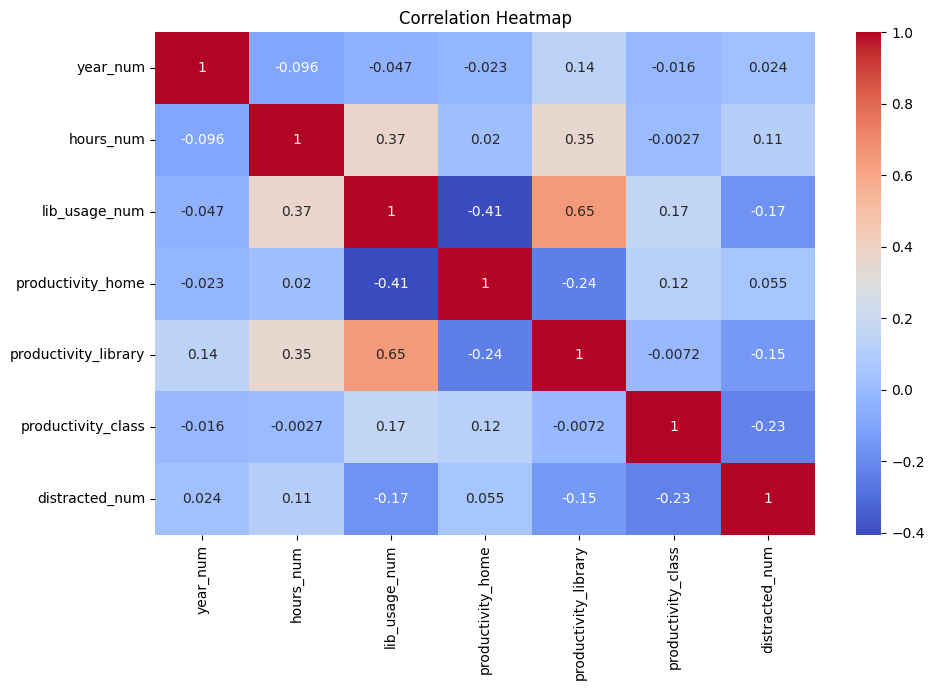

In [23]:

enc = df.copy()

enc["year_num"] = enc["year"].map({"Year 1":1, "Year 2":2, "Year 3":3, "Year 4":4})
enc["hours_num"] = enc["daily_study_hours"].map({"<2 hrs":1, "2-4 hrs":2, ">4 hrs":3})
enc["lib_usage_num"] = enc["library_usage"].map({"Never":1, "Rarely":2, "Sometimes":3, "Regularly":4})
enc["distracted_num"] = enc["easily_distracted"].map({"No":1, "Sometimes":2, "Yes":3})

# pick useful columns only
corr = enc[[
    "year_num",
    "hours_num",
    "lib_usage_num",
    "productivity_home",
    "productivity_library",
    "productivity_class",
    "distracted_num"]].corr()

plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

- Library usage and library productivity show a positive correlation — students who go more often feel more productive there.
- Study hours have a mild positive relationship with overall productivity across all locations.
- Distraction level doesn't strongly correlate with productivity scores, which is a bit unexpected.
- Study routine shows a weak positive link with productivity — having a routine helps slightly but isn't the strongest factor.
- Exam intensity has very little correlation with productivity ratings — cramming more during exams doesn't necessarily mean feeling more productive.
- Overall, no single variable strongly predicts productivity on its own.

###  BASIC MODEL Building

Objective : 

The goal of this model is to predict where a student is most likely to study (Hostel, Library, or Lab/Classroom) based on their study habits and productivity patterns.

Model Used :

Two classification models were tested — Logistic Regression and Random Forest Classifier. Random Forest was the primary focus as it also provides feature importance, which is more useful for analysis.

Features Used The following variables were used as input to the model:

Year of study
Daily study hours
Library usage frequency
Study routine
Distraction level
Productivity ratings at Home, Library, and Classroom

C:\Users\902pu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


CV Accuracy: 0.83 (+/- 0.04)


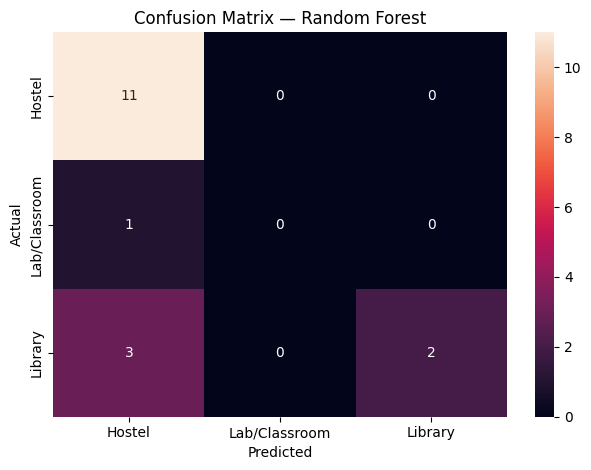

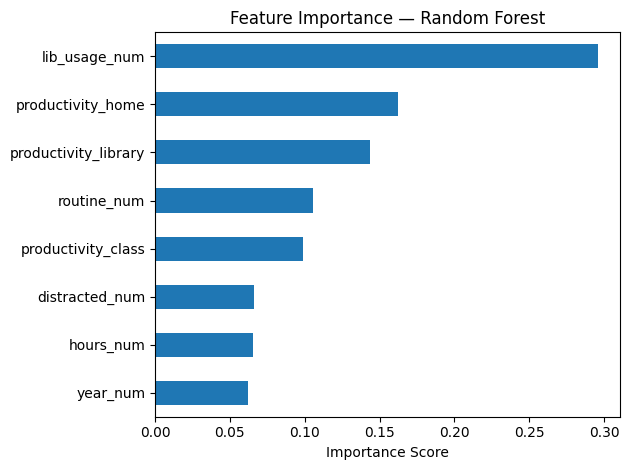

year_num                0.061792
hours_num               0.065711
distracted_num          0.065853
productivity_class      0.099097
routine_num             0.105499
productivity_library    0.143581
productivity_home       0.162558
lib_usage_num           0.295909
dtype: float64


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


model_df = df.copy()
# model_df = model_df[model_df["avg_productivity"] > 0]

model_df["year_num"]       = model_df["year"].map({"Year 1":1,"Year 2":2,"Year 3":3,"Year 4":4,"Final Year":5,"PhD":6})
model_df["hours_num"]      = model_df["daily_study_hours"].map({"<2 hrs":1,"2-4 hrs":2,">4 hrs":3})
model_df["lib_usage_num"]  = model_df["library_usage"].map({"Never":1,"Rarely":2,"Sometimes":3,"Regularly":4})
model_df["routine_num"]    = model_df["study_routine"].map({"No":1,"During Exams":2,"Yes":3})
model_df["distracted_num"] = model_df["easily_distracted"].map({"No":1,"Sometimes":2,"Yes":3})


features = ["year_num","hours_num","lib_usage_num","routine_num","distracted_num",
            "productivity_home","productivity_library","productivity_class"]
target   = "primary_location"

X = model_df[features].dropna()
y = model_df.loc[X.index, target]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)


rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

cv_scores = cross_val_score(rf, X, y, cv=5, scoring="accuracy")
print(f"CV Accuracy: {cv_scores.mean():.2f} (+/- {cv_scores.std():.2f})")

cm = confusion_matrix(y_test, y_pred_rf, labels=rf.classes_)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=rf.classes_, yticklabels=rf.classes_)
plt.title("Confusion Matrix — Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


importance = pd.Series(rf.feature_importances_, index=features).sort_values()
importance.plot(kind="barh")
plt.title("Feature Importance — Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print(importance)


The test set showed that both models were 76% accurate, and cross-validation showed that they were 83% accurate, which is pretty good for a dataset of only 83 students.

Confusion Matrix :

- All 11 Hostel students were correctly predicted.
- The 1 Lab/Classroom student was misclassified as Hostel.
- Out of 5 Library students, only 2 were correctly predicted and 3 were misclassified as Hostel.
- The model has a bias towards predicting Hostel, simply because it dominates the dataset.

Feature Importance

The most influential features in predicting study location were:

Library Usage (0.31) — strongest predictor by far, which makes total sense
Productivity at Home (0.16) — students who feel productive at home tend to stay there
Productivity at Library (0.13) — students who rate library high are more likely to go there
Study Routine (0.11) — students with a fixed routine are slightly more likely to use the library
Year, Study Hours and Distraction level had relatively lower influence

Key Takeaway
Library usage frequency is the single biggest factor in determining where a student studies. Productivity perception at each location also plays a significant role — students pivot where they feel most productive. The model works well for the majority class (Hostel) but struggles with classes due to limited data.

Prediction Model :

In [28]:
new_data = pd.DataFrame([{
    "year": "Year 2",
    "daily_study_hours": "2-4 hrs",
    "library_usage": "Sometimes",
    "study_routine": "Yes",
    "easily_distracted": "Sometimes",
    "productivity_home": 3,
    "productivity_library": 4,
    "productivity_class": 3
}])

new_data["year_num"]       = new_data["year"].map({"Year 1":1,"Year 2":2,"Year 3":3,"Year 4":4,"Final Year":5,"PhD":6})
new_data["hours_num"]      = new_data["daily_study_hours"].map({"<2 hrs":1,"2-4 hrs":2,">4 hrs":3})
new_data["lib_usage_num"]  = new_data["library_usage"].map({"Never":1,"Rarely":2,"Sometimes":3,"Regularly":4})
new_data["routine_num"]    = new_data["study_routine"].map({"No":1,"During Exams":2,"Yes":3})
new_data["distracted_num"] = new_data["easily_distracted"].map({"No":1,"Sometimes":2,"Yes":3})

X_new = new_data[features]


if X_new.isnull().any().any():
    print("Error: Invalid input category detected")
else:
   
    prediction = lr.predict(X_new)
    print("Predicted Primary Study Location:", prediction[0])

Predicted Primary Study Location: Library


## Highlights :

- 67.5% study at hostel even though library scores highest for productivity
- Mean productivity :Library = 3, Hostel = 2.5, Class = 2
- 84% get distracted — mobile phones and social media are top reasons
- Students know library is better but still don't go.
- Library usage is the strongest predictor of study location (feature importance = 0.31)
- Exam time — most students study more but don't change location